Do you want to see the data without cleaning cuts? Well you are in the right place!
<br>
Here you can explore the Sophronia/Dorothea reconstructed data.
<br>

__NOTE:__ _information here come from the 2025 alphas commissioning phase._

In [1]:
import sys
sys.path.append('/lhome/ific/c/ccortesp/Analysis')

from libs import crudo

from iminuit import Minuit
from iminuit.cost import LeastSquares
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

# Styling Plot
crudo.pt.ccortesp_plot_style()

%matplotlib inline
%load_ext autoreload
%autoreload 2

Crudo package loaded successfully.
Available sub-modules: data_management (dm), energy_functions (ef), fit_functions (ff), plotting_tools (pt), topology_functions (tf), utilities (ut).


# Preliminary

In [2]:
# α runs!
RUNS_INFO = [    
                # # --- Cold-Getter: Jan 17th --- #
                # {"run_number": 14714, "duration": 64574, "OK": 1909287, "LOST": 1728359, "real_rate": 56.333},
                # # {"run_number": 14715, "duration": 84365, "OK": 2469062, "LOST": 2239303, "real_rate": 55.809},      # Waveforms in magnetic tape, not processed
                # {"run_number": 14716, "duration": 17036, "OK": 495769 , "LOST": 451306 , "real_rate": 55.592},
                # {"run_number": 14720, "duration": 48518, "OK": 1432110, "LOST": 1294941, "real_rate": 56.207},      # Estimated from fit
                # {"run_number": 14733, "duration": 53881, "OK": 1587637, "LOST": 1429629, "real_rate": 55.998},
                # {"run_number": 14735, "duration": 84987, "OK": 2508569, "LOST": 2267982, "real_rate": 56.203},
                # {"run_number": 14737, "duration": 72705, "OK": 2153786, "LOST": 1960347, "real_rate": 56.586},
                {"run_number": 14739, "duration": 87138, "OK": 2576630, "LOST": 2334343, "real_rate": 56.358},
                # {"run_number": 14741, "duration": 87755, "OK": 2592615, "LOST": 2349583, "real_rate": 56.318},
                # {"run_number": 14743, "duration": 82332, "OK": 2437984, "LOST": 2220643, "real_rate": 56.583},
                # {"run_number": 14745, "duration": 60990, "OK": 1803415, "LOST": 1636317, "real_rate": 56.398},

                # # --- Hot-Getter: Jan 27th --- #
                # {"run_number": 14753, "duration": 86308, "OK": 2188547, "LOST": 1532351, "real_rate": 43.111},
                # {"run_number": 14765, "duration": 55978, "OK": 1259832, "LOST": 735202 , "real_rate": 35.639},
                # {"run_number": 14776, "duration": 47397, "OK": 957081 , "LOST": 481810 , "real_rate": 30.358},        # Data removed
                # {"run_number": 14780, "duration": 88503, "OK": 1600797, "LOST": 682246 , "real_rate": 25.796},
                # # Feb 2025
                # {"run_number": 14782, "duration": 85654, "OK": 1382153, "LOST": 506234 , "real_rate": 22.046},
                # {"run_number": 14784, "duration": 57290, "OK": 842541 , "LOST": 273581 , "real_rate": 19.481},
                # {"run_number": 14789, "duration": 74148, "OK": 976360 , "LOST": 277504 , "real_rate": 16.910},
                # # --- Zero Suppression --- #
                # {"run_number": 14803, "duration": 71721, "OK": 933727 , "LOST": 104677 , "real_rate": 14.478},
                # {"run_number": 14804, "duration": 65116, "OK": 680552 , "LOST": 156995 , "real_rate": 12.862},
                # # --- NO Zero Suppression --- #
                # {"run_number": 14811, "duration": 84651, "OK": 782816 , "LOST": 147773 , "real_rate": 10.993},
                # {"run_number": 14814, "duration": 6344 , "OK": 55679  , "LOST": 10155  , "real_rate": 10.377},
                # {"run_number": 14815, "duration": 86232, "OK": 717786 , "LOST": 121527 , "real_rate": 9.733 },
                # {"run_number": 14816, "duration": 86580, "OK": 659265 , "LOST": 101374 , "real_rate": 8.785 },
                # {"run_number": 14817, "duration": 49662, "OK": 352203 , "LOST": 50474  , "real_rate": 8.108 },
                # {"run_number": 14828, "duration": 53609, "OK": 300827 , "LOST": 100405 , "real_rate": 7.484 },
                # {"run_number": 14829, "duration": 73042, "OK": 387003 , "LOST": 121249 , "real_rate": 6.958 },
                # {"run_number": 14834, "duration": 5779 , "OK": 32864  , "LOST": 3887   , "real_rate": 6.359 },
                # {"run_number": 14835, "duration": 11713, "OK": 66515  , "LOST": 7358   , "real_rate": 6.306 },
                # {"run_number": 14837, "duration": 55751, "OK": 294175 , "LOST": 31034  , "real_rate": 5.833 },
                # {"run_number": 14838, "duration": 87854, "OK": 431766 , "LOST": 42219  , "real_rate": 5.395 },
                # {"run_number": 14839, "duration": 84881, "OK": 401004 , "LOST": 37747  , "real_rate": 5.169 },
                # {"run_number": 14840, "duration": 56174, "OK": 260266 , "LOST": 23627  , "real_rate": 5.054 }  
            ]

### Reconstructed

In [3]:
RECO_DATA = {run["run_number"]: crudo.dm.load_run_data(run, trigger=None)[run["run_number"]] for run in RUNS_INFO}

/DST/Events: Run 14739 successfully loaded with data shape: (403582, 26)


# Cuts Performance

In [4]:
# Define the runs to analyze
SEL_RUNS = [14739]

## Base Distributions (NO cuts!)

### Radial

Run 14739 - R² range: [1.55, 1999996000002.00] mm²


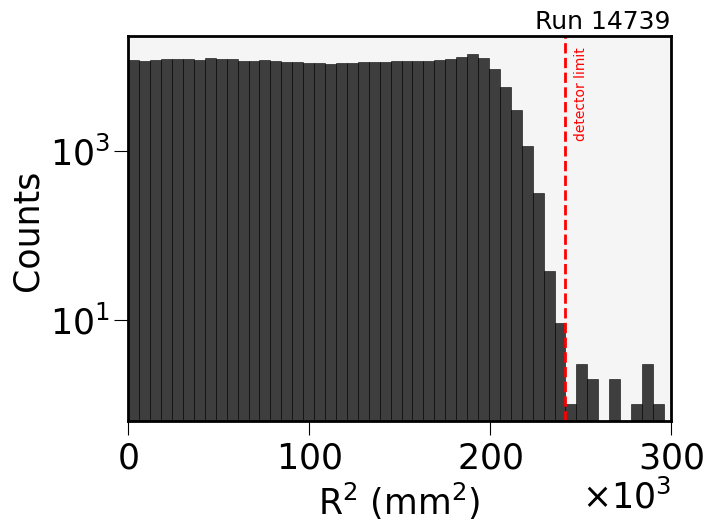

In [5]:
# Global
n_bins = 50

for i, entry in enumerate(RUNS_INFO):
    
    # Run info
    run_id   = entry["run_number"]    
    run_long = entry["duration"]

    if run_id in SEL_RUNS:
        
        # Variables
        R2 = RECO_DATA[run_id]['X']**2 + RECO_DATA[run_id]['Y']**2
        print(f"Run {run_id} - R² range: [{R2.min():.2f}, {R2.max():.2f}] mm²")
        
        # Histogram
        plt.figure(figsize=(7, 5))
        counts, bins, _ = plt.hist(R2, bins=n_bins, range=(R2.min(), 1.25*crudo.pt.N100_rad**2),
                                   color=crudo.pt.hist_colors[i % len(crudo.pt.hist_colors)], alpha=0.75,
                                   ec=crudo.pt.hist_colors[i % len(crudo.pt.hist_colors)], lw=0.5)
        
        # Plot
        plt.xlim(0, 300e3)
        plt.xlabel('R$^{2}$ (mm$^{2}$)')
        plt.ylabel('Counts')
        plt.yscale('log')
        plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
        plt.title(f'Run {run_id}', fontsize=18, loc='right')

        # Radial limit
        plt.axvline(x=crudo.pt.N100_rad**2, c='red', ls='--')
        plt.text(1.02*crudo.pt.N100_rad**2, 0.4*counts[0], 'detector limit', c='red', va='center',  ha='left',  rotation=90, fontsize=10)

        plt.gca().set_facecolor("whitesmoke")
        plt.show()

### DT

Run 14739 - ΔT range: [-999999.00, 2598.99] μs
Run 14739: There are 1 negative DT values.


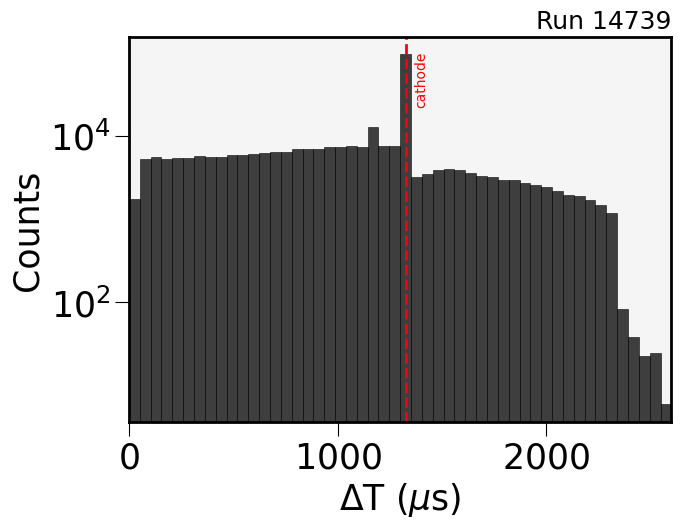

In [6]:
# Global
n_bins = 50

for i, entry in enumerate(RUNS_INFO):
    
    # Run info
    run_id   = entry["run_number"]
    run_long = entry["duration"]

    if run_id in SEL_RUNS:
        
        # Variables
        DT = RECO_DATA[run_id]['DT']
        print(f"Run {run_id} - ΔT range: [{DT.min():.2f}, {DT.max():.2f}] μs")
        
        # Histogram
        plt.figure(figsize=(7, 5))
        counts, bins, _ = plt.hist(DT, bins=n_bins, range=(0, DT.max()),
                                   color=crudo.pt.hist_colors[i % len(crudo.pt.hist_colors)], alpha=0.75,
                                   ec=crudo.pt.hist_colors[i % len(crudo.pt.hist_colors)], lw=0.5)
        
        # Estimated cathode time position + error
        cath_index   = np.argmax(counts)                                                     # Index of the bin with the highest count
        cath_central = (bins[cath_index] + bins[cath_index + 1]) / 2 
        cath_error   = (bins[1] - bins[0]) / 2 

        # Negative DT's?
        negative_DT = RECO_DATA[run_id][DT < 0]    
        if not negative_DT.empty:
            print(f"Run {run_id}: There are {len(negative_DT)} negative DT values.")
        else:
            print(f"Run {run_id}: No negative DT values found.")
        
        # Plot
        plt.xlim(0, DT.max())
        plt.xlabel('$\Delta$T ($\mu$s)')
        plt.ylabel('Counts')
        plt.yscale('log')
        plt.title(f'Run {run_id}', fontsize=18, loc='right')
        
        # Cathode line
        plt.axvline(x=cath_central, c='red', ls='--')
        plt.text(1.03*cath_central, 0.5*counts[cath_index], 'cathode', c='red', va='center',  ha='left',  rotation=90, fontsize=10)

        plt.gca().set_facecolor("whitesmoke")
        plt.show()

### $S1$ Pulse

Run 14739 - S1 Width range: [0.50, 4.00] μs


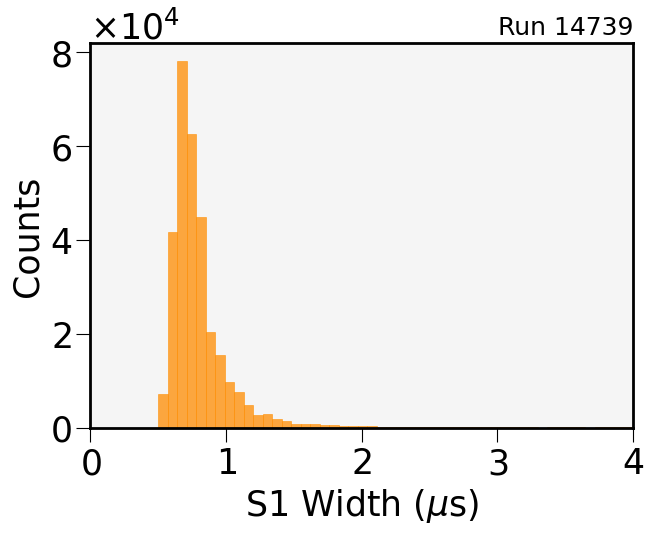

In [7]:
# Global
n_bins = 50

for i, entry in enumerate(RUNS_INFO):
    
    # Run info
    run_id   = entry["run_number"]
    run_long = entry["duration"]

    if run_id in SEL_RUNS:
        
        # Variables
        W1 = RECO_DATA[run_id]['S1w'] / 1e3  # [μs]
        print(f"Run {run_id} - S1 Width range: [{W1.min():.2f}, {W1.max():.2f}] μs")
        
        # Histogram
        plt.figure(figsize=(7, 5))
        counts, bins, _ = plt.hist(W1, bins=n_bins,
                                   color=crudo.pt.hist_colors[(i + 2) % len(crudo.pt.hist_colors)], alpha=0.75,
                                   ec=crudo.pt.hist_colors[(i + 2) % len(crudo.pt.hist_colors)], lw=0.5)
        
        # Plot
        plt.xlim(0, W1.max())
        plt.xlabel('S1 Width ($\mu$s)')
        plt.ylabel('Counts')
        # plt.yscale('log')
        plt.title(f'Run {run_id}', fontsize=18, loc='right')

        plt.gca().set_facecolor("whitesmoke")
        plt.show()

Run 14739 - S1 Energy range: [400.02, 394848.16] PE


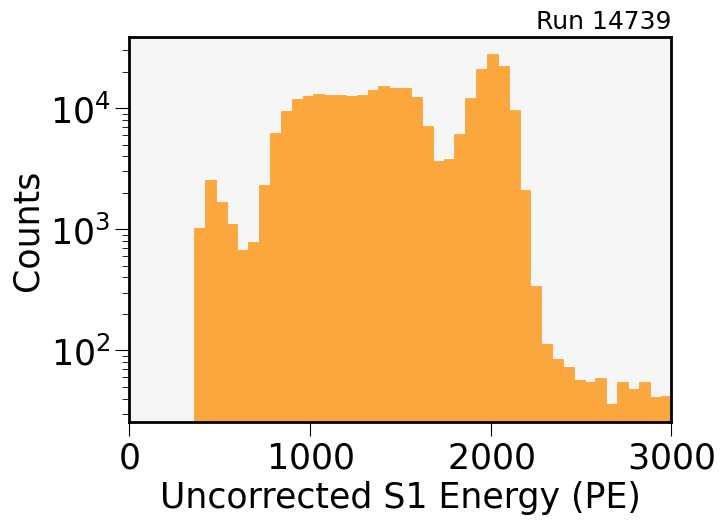

In [8]:
# Global
n_bins = 50
x_min, x_max = 0, 3e3
x_edges = np.linspace(x_min, x_max, n_bins + 1)     # There are NaN values, so we need to set the range manually to avoid errors

for i, entry in enumerate(RUNS_INFO):
    
    # Run info
    run_id   = entry["run_number"]
    run_long = entry["duration"]

    if run_id in SEL_RUNS:

        # Variables
        E1 = RECO_DATA[run_id]['S1e']
        print(f"Run {run_id} - S1 Energy range: [{E1.min():.2f}, {E1.max():.2f}] PE")

        # Histogram
        E1_counts, E1_edges = np.histogram(E1, bins=x_edges)

        # Histogram
        plt.figure(figsize=(7, 5))
        plt.stairs(E1_counts, E1_edges,
                   fill=True, color=crudo.pt.hist_colors[(i + 2) % len(crudo.pt.hist_colors)], alpha=0.75,
                   ec=crudo.pt.hist_colors[(i + 2) % len(crudo.pt.hist_colors)], lw=0.5,)
        
        # Plot
        plt.xlim(x_min, x_max)
        plt.xlabel('Uncorrected S1 Energy (PE)')
        plt.ylabel('Counts')
        plt.yscale('log')
        plt.title(f'Run {run_id}', fontsize=18, loc='right')

        plt.gca().set_facecolor("whitesmoke")
        plt.show()

Run 14739 - S1 Time range: [0.00, 1579.92] μs


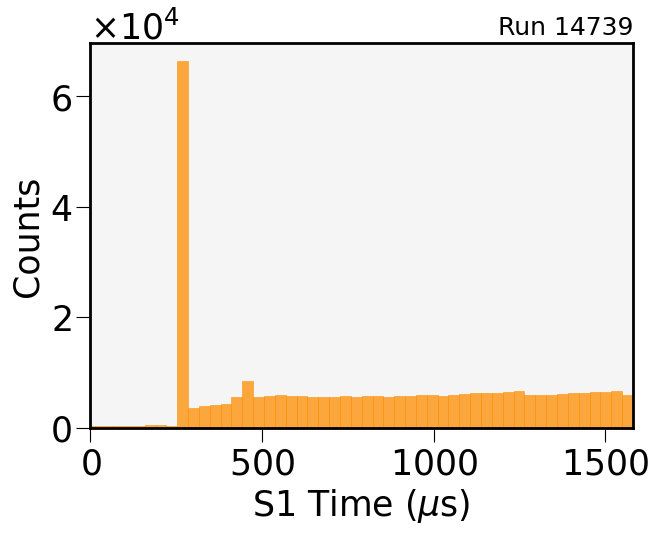

In [9]:
# Global
n_bins =50

for i, entry in enumerate(RUNS_INFO):
    
    # Run info
    run_id   = entry["run_number"]
    run_long = entry["duration"]

    if run_id in SEL_RUNS:
        
        # Variables
        T1 = RECO_DATA[run_id]['S1t'] / 1e3  # [μs]
        print(f"Run {run_id} - S1 Time range: [{T1.min():.2f}, {T1.max():.2f}] μs")
        
        # Histogram
        plt.figure(figsize=(7, 5))
        counts, bins, _ = plt.hist(T1, bins=n_bins,
                                   color=crudo.pt.hist_colors[(i + 2) % len(crudo.pt.hist_colors)], alpha=0.75,
                                   ec=crudo.pt.hist_colors[(i + 2) % len(crudo.pt.hist_colors)], lw=0.5)
        
        # Plot
        plt.xlim(T1.min(), T1.max())
        plt.xlabel('S1 Time ($\mu$s)')
        plt.ylabel('Counts')
        # plt.yscale('log')
        plt.title(f'Run {run_id}', fontsize=18, loc='right')

        plt.gca().set_facecolor("whitesmoke")
        plt.show()

### $S2$ Pulse

Run 14739 - S2 width range: [10.00 - 1020.00] μs


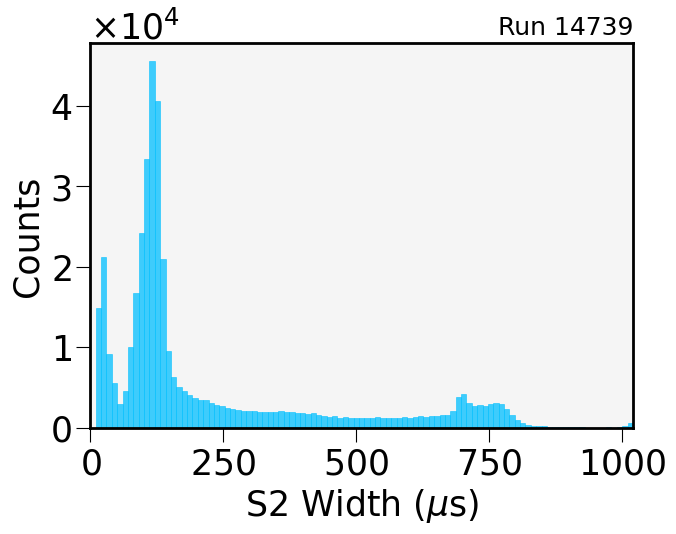

In [ ]:
# Global
n_bins = 100

for i, entry in enumerate(RUNS_INFO):
    
    # Run info
    run_id   = entry["run_number"]
    run_long = entry["duration"]

    if run_id in SEL_RUNS:
        
        # Variables
        W2 = RECO_DATA[run_id]['S2w']
        print(f"Run {run_id} - S2 width range: [{W2.min():.2f} - {W2.max():.2f}] μs")
        
        # Histogram
        plt.figure(figsize=(7, 5))
        counts, bins, _ = plt.hist(W2, bins=n_bins,
                                   color=crudo.pt.hist_colors[(i + 3) % len(crudo.pt.hist_colors)], alpha=0.75,
                                   ec=crudo.pt.hist_colors[(i + 3) % len(crudo.pt.hist_colors)], lw=0.5)
        
        # Plot
        plt.xlim(0, W2.max())
        plt.xlabel('S2 Width ($\mu$s)')
        plt.xticks(bins, rotation=90, fontsize=5)
        plt.ylabel('Counts')
        # plt.yscale('log')
        plt.title(f'Run {run_id}', fontsize=18, loc='right')

        plt.gca().set_facecolor("whitesmoke")
        plt.show()

Run 14739 - S2 Energy range: [40001.49, 3979737.75] PE


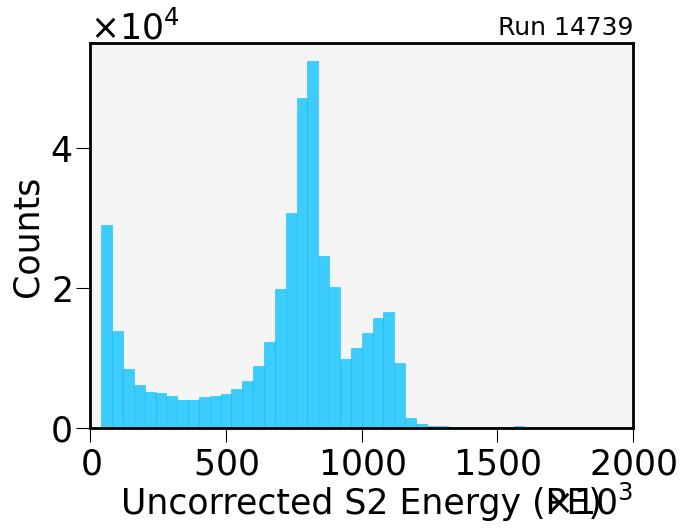

In [11]:
# Global
n_bins = 50
x_min, x_max = 0, 2000e3
x_edges = np.linspace(x_min, x_max, n_bins + 1)     # There are some events with greater energy

for i, entry in enumerate(RUNS_INFO):
    
    # Run info
    run_id   = entry["run_number"]
    run_long = entry["duration"]

    if run_id in SEL_RUNS:
        
        # Variables
        E2 = RECO_DATA[run_id]['S2e']
        print(f"Run {run_id} - S2 Energy range: [{E2.min():.2f}, {E2.max():.2f}] PE")
        
        # Histogram
        plt.figure(figsize=(7, 5))
        counts, bins, _ = plt.hist(E2, bins=x_edges, 
                                   color=crudo.pt.hist_colors[(i + 3) % len(crudo.pt.hist_colors)], alpha=0.75,
                                   ec=crudo.pt.hist_colors[(i + 3) % len(crudo.pt.hist_colors)], lw=0.5)
        
        # Plot
        plt.xlim(0, x_max)
        plt.xlabel('Uncorrected S2 Energy (PE)')
        plt.ylabel('Counts')
        # plt.yscale('log')
        plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
        plt.title(f'Run {run_id}', fontsize=18, loc='right')

        plt.gca().set_facecolor("whitesmoke")
        plt.show()

Run 14739 - S2 Time range: [1580.99, 2599.55] μs


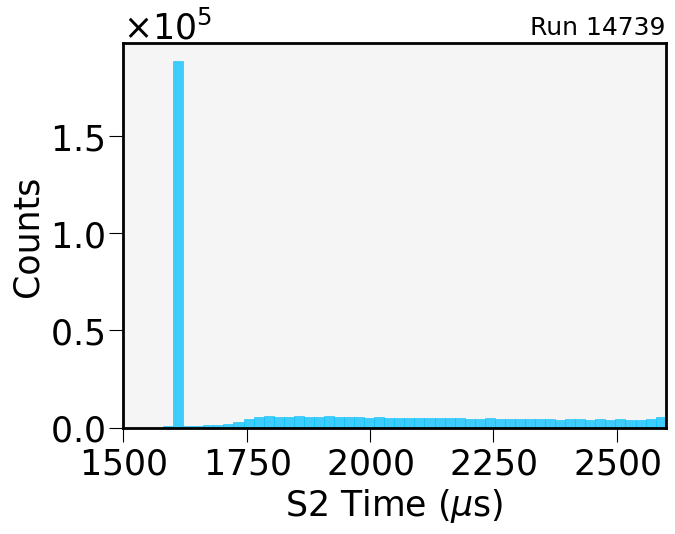

In [12]:
# Global
n_bins = 50

for i, entry in enumerate(RUNS_INFO):
    
    # Run info
    run_id   = entry["run_number"]
    run_long = entry["duration"]

    if run_id in SEL_RUNS:
        
        # Variables
        T2 = RECO_DATA[run_id]['S2t'] / 1e3  # [μs]
        print(f"Run {run_id} - S2 Time range: [{T2.min():.2f}, {T2.max():.2f}] μs")
        
        # Histogram
        plt.figure(figsize=(7, 5))
        counts, bins, _ = plt.hist(T2, bins=n_bins,
                                   color=crudo.pt.hist_colors[(i + 3) % len(crudo.pt.hist_colors)], alpha=0.75,
                                   ec=crudo.pt.hist_colors[(i + 3) % len(crudo.pt.hist_colors)], lw=0.5)
        
        # Plot
        plt.xlim(1500, T2.max())
        plt.xlabel('S2 Time ($\mu$s)')
        plt.ylabel('Counts')
        # plt.yscale('log')
        plt.title(f'Run {run_id}', fontsize=18, loc='right')

        plt.gca().set_facecolor("whitesmoke")
        plt.show()

## Po-like Population

There is a population of mis-reconstructed alpha candidates near to the cathode.
<br>
These events have similar energy to $^{214}\text{Po}$, that's why the name.
<br>
Here, we define the cut to use in order to avoid this population.

Run 14739:
  - S1 Height range: [50.00, 4000.41] PE
  - S1 Energy range: [400.02, 394848.16] PE
 Fit line: m = (0.17 ± 0.00), b = (2.05 ± 0.11) PE
           χ²/ndof = 7.0193
 Po-like masking line: slope = 0.17, intercept = -56 PE


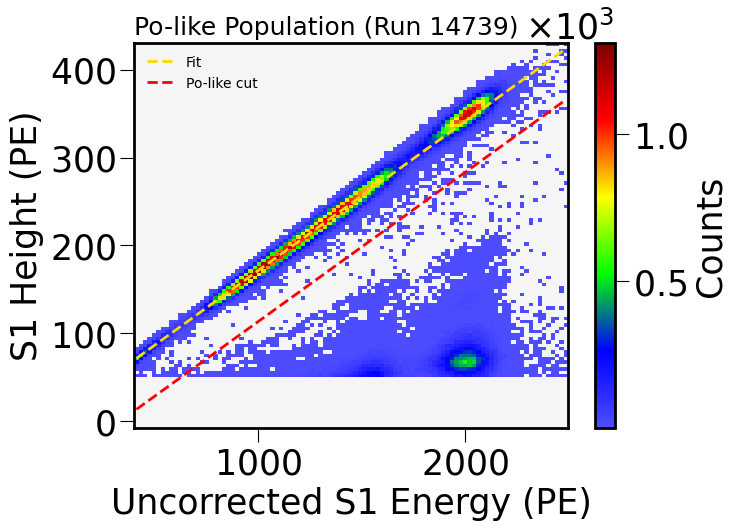

In [13]:
# Global
n_bins = 100
Po_intercept = -56     # Computed using the fit line slope and a desire point: (1800, 250)

for i, entry in enumerate(RUNS_INFO):

    # Run info
    run_id   = entry["run_number"]
    run_long = entry["duration"]

    if run_id in SEL_RUNS:

        print(f"Run {run_id}:")

        # Variables
        H1 = RECO_DATA[run_id]['S1h']
        E1 = RECO_DATA[run_id]['S1e']
        print(f"  - S1 Height range: [{H1.min():.2f}, {H1.max():.2f}] PE")
        print(f"  - S1 Energy range: [{E1.min():.2f}, {E1.max():.2f}] PE")

        # Masking: ignore outliers and focus on the region of interest
        mask = (H1 >= H1.min()) & (H1 <= 800) & \
               (E1 >= E1.min()) & (E1 <= 2.5e3)
        H1_mask = H1[mask]
        E1_mask = E1[mask]

        # 2D histogram
        S1h_S1e_map, ex, ey = crudo.pt.hist_2D(E1_mask, H1_mask, x_bins=n_bins, y_bins=n_bins)
        S1h_S1e_map         = np.ma.masked_where(S1h_S1e_map==0, S1h_S1e_map)   # Zero values masked

        # --- Linear Fit --- #
        # Compute representative values for the fit
        E1_centers, E1_errors, S1h_centers, S1h_errors = crudo.ff.prefit_2D(E1_mask, H1_mask, bins=ex, stat='median')
        # Filter out points with zero error (bins with 1 event)
        valid_points = S1h_errors > 0
        E1_centers  = E1_centers[valid_points];      E1_errors  = E1_errors[valid_points]
        S1h_centers = S1h_centers[valid_points];     S1h_errors = S1h_errors[valid_points]

        # Definte the cost function + initial guess
        least_squares = LeastSquares(E1_centers, S1h_centers, S1h_errors, crudo.ff.linear_func)
        init_guess = [10, S1h_centers.min()]

        # Define the Minuit object
        m = Minuit(least_squares, *init_guess)

        # Minimization process of the cost function and error estimation
        m.migrad();     m.hesse()

        # Results
        popt = m.values;  perr = m.errors
        print(f' Fit line: m = ({popt[0]:.2f} ± {perr[0]:.2f}), b = ({popt[1]:.2f} ± {perr[1]:.2f}) PE')

        # Reduced chi-square
        chi2 = m.fval
        ndof = len(E1_centers) - m.nfit
        print(f"           χ²/ndof = {chi2 / ndof:.4f}")

        # --- Plotting --- #
        plt.figure(figsize=(7, 5))

        # Data
        plt.pcolormesh(ex, ey, S1h_S1e_map.T, cmap=crudo.pt.custom_hsv, shading='auto')
        cbar = plt.colorbar(label='Counts', shrink=1.0)
        cbar.formatter.set_powerlimits((0, 0))

        # Fit
        fit_y = crudo.ff.linear_func(E1_centers, *popt)
        # plt.errorbar(E1_centers, S1h_centers, xerr=E1_errors, yerr=S1h_errors, fmt='o', c='black', ecolor='black', lw=1.0, markersize=5)
        plt.plot(E1_centers, fit_y, c='gold', ls='--', zorder=3, label='Fit')

        # Masking line
        print(f' Po-like masking line: slope = {popt[0]:.2f}, intercept = {Po_intercept} PE')
        mask_y = crudo.ff.linear_func(E1_centers, popt[0], Po_intercept)
        plt.plot(E1_centers, mask_y, c='red', ls='--', zorder=4, label='Po-like cut')

        # --- Styling --- #
        plt.xlim(E1_mask.min(), E1_mask.max())
        plt.xlabel('Uncorrected S1 Energy (PE)')
        plt.ylabel('S1 Height (PE)')
        plt.legend(loc='upper left', fontsize=10, facecolor='None')
        plt.title (f'Po-like Population (Run {run_id})', fontsize=18, loc='left')
        
        plt.gca().set_facecolor("whitesmoke")
        plt.show()

## Primary Selection

We first group the dataframes of interest by event to perform selection at event-level and compute the selection efficiency.

In [5]:
# Store the selected dataframes
SEL_DATA = {run["run_number"]: pd.DataFrame() for run in RUNS_INFO}

for i, entry in enumerate(RUNS_INFO):

    # Run info
    run_id = entry["run_number"]

    # Apply selection criteria only to chosen runs    
    if run_id in SEL_RUNS:

        # Total number of events
        total_events = RECO_DATA[run_id]['event'].nunique()

        print(f"Run {run_id} - Selection Efficiency:")
        print(f"  - Initially: {total_events} events")

        # Start with full dataset
        df_selected = RECO_DATA[run_id]

        # Define cuts and labels
        selection_cuts = [
                                ("Multiplicities", lambda x: (x['nS1'].sum() == 1) & (x['nS2'].sum() == 1)),
                                ("S1 Width",       lambda x: (        x['S1w'].sum() < 1250  )),
                                ("S1 Time",        lambda x: (150e3 < x['S1t'].sum()         )),
                                ("S2 Width",       lambda x: (        x['S2w'].sum() < 250   )),                # We understand the right tail!
                                ("S2 Time",        lambda x: (        x['S2t'].sum() < 1650e3)),
                                ("Po-like cut",    lambda x: (x['S1h'].sum() >= 0.17 * x['S1e'].sum() - 56))    # Reject (>=) or select (<)
                         ]

        # Apply each cut step by step        
        for label, condition in selection_cuts:
            
            df_selected = df_selected.groupby('event').filter(condition)
            rem_events  = df_selected['event'].nunique()
            
            print(f"  - After {label}: {rem_events} events ({(rem_events / total_events) * 100:.2f}%)")     # Global efficiencies

        # Store final selected data
        SEL_DATA[run_id] = df_selected

Run 14739 - Selection Efficiency:
  - Initially: 339737 events
  - After Multiplicities: 200353 events (58.97%)
  - After S1 Width: 192605 events (56.69%)
  - After S1 Time: 192432 events (56.64%)
  - After S2 Width: 151271 events (44.53%)
  - After S2 Time: 111411 events (32.79%)
  - After Po-like cut: 96087 events (28.28%)


## Base Distributions (with cuts!)

How did the relevant distribution change?

### Radial

Run 14739 - R² range: [1.60, 237345.68] mm²


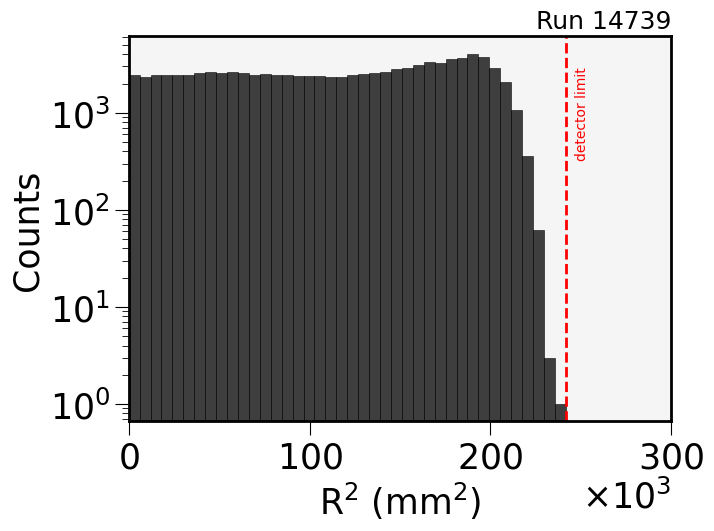

In [6]:
# Global
n_bins = 50

for i, entry in enumerate(RUNS_INFO):
    
    # Run info
    run_id   = entry["run_number"]
    run_long = entry["duration"]

    if run_id in SEL_RUNS:
        
        # Variables
        R2 = SEL_DATA[run_id]['X']**2 + SEL_DATA[run_id]['Y']**2
        print(f"Run {run_id} - R² range: [{R2.min():.2f}, {R2.max():.2f}] mm²")
        
        # Histogram
        plt.figure(figsize=(7, 5))
        counts, bins, _ = plt.hist(R2, bins=n_bins, range=(R2.min(), 1.25*crudo.pt.N100_rad**2),
                                   color=crudo.pt.hist_colors[i % len(crudo.pt.hist_colors)], alpha=0.75,
                                   ec=crudo.pt.hist_colors[i % len(crudo.pt.hist_colors)], lw=0.5)
        
        # Plot
        plt.xlim(0, 300e3)
        plt.xlabel('R$^{2}$ (mm$^{2}$)')
        plt.ylabel('Counts')
        plt.yscale('log')
        plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
        plt.title(f'Run {run_id}', fontsize=18, loc='right')

        # Radial limit
        plt.axvline(x=crudo.pt.N100_rad**2, c='red', ls='--')
        plt.text(1.02*crudo.pt.N100_rad**2, 0.4*counts[0], 'detector limit', c='red', va='center',  ha='left',  rotation=90, fontsize=10)

        plt.gca().set_facecolor("whitesmoke")
        plt.show()

### DT

Run 14739 - ΔT range: [24.13, 1467.34] μs
Run 14739: No negative DT values found.


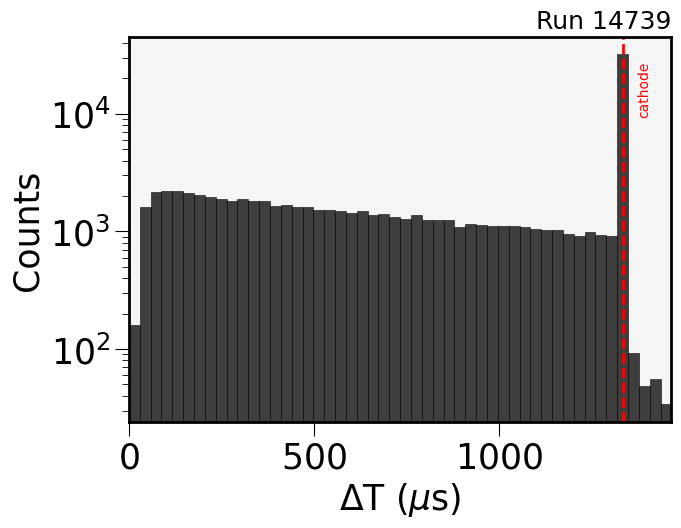

In [7]:
# Global
n_bins = 50

for i, entry in enumerate(RUNS_INFO):
    
    # Run info
    run_id   = entry["run_number"]
    run_long = entry["duration"]

    if run_id in SEL_RUNS:
        
        # Variables
        DT = SEL_DATA[run_id]['DT']
        print(f"Run {run_id} - ΔT range: [{DT.min():.2f}, {DT.max():.2f}] μs")
        
        # Histogram
        plt.figure(figsize=(7, 5))
        counts, bins, _ = plt.hist(DT, bins=n_bins, range=(0, DT.max()),
                                   color=crudo.pt.hist_colors[i % len(crudo.pt.hist_colors)], alpha=0.75,
                                   ec=crudo.pt.hist_colors[i % len(crudo.pt.hist_colors)], lw=0.5)
        
        # Estimated cathode time position + error
        cath_index   = np.argmax(counts)                                                     # Index of the bin with the highest count
        cath_central = (bins[cath_index] + bins[cath_index + 1]) / 2 
        cath_error   = (bins[1] - bins[0]) / 2 

        # Negative DT's?
        negative_DT = SEL_DATA[run_id][DT < 0]    
        if not negative_DT.empty:
            print(f"Run {run_id}: There are {len(negative_DT)} negative DT values.")
        else:
            print(f"Run {run_id}: No negative DT values found.")
        
        # Plot
        plt.xlim(0, DT.max())
        plt.xlabel('$\Delta$T ($\mu$s)')
        plt.ylabel('Counts')
        plt.yscale('log')
        plt.title(f'Run {run_id}', fontsize=18, loc='right')

        # Cathode line
        plt.axvline(x=cath_central, c='red', ls='--')
        plt.text(1.03*cath_central, 0.5*counts[cath_index], 'cathode', c='red', va='center',  ha='left',  rotation=90, fontsize=10)

        plt.gca().set_facecolor("whitesmoke")
        plt.show()

### Energies

Run 14739 - S1 Energy range: [400.78, 2622.57] PE


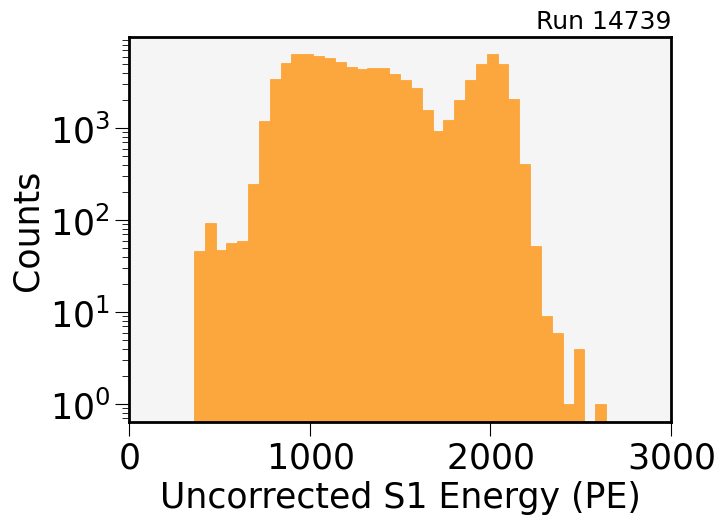

In [9]:
# Global
n_bins = 50
x_min, x_max = 0, 3e3
x_edges = np.linspace(x_min, x_max, n_bins + 1)     # There are NaN values, so we need to set the range manually to avoid errors

for i, entry in enumerate(RUNS_INFO):
    
    # Run info
    run_id   = entry["run_number"]
    run_long = entry["duration"]

    if run_id in SEL_RUNS:

        # Variables
        E1 = SEL_DATA[run_id]['S1e']
        print(f"Run {run_id} - S1 Energy range: [{E1.min():.2f}, {E1.max():.2f}] PE")

        # Histogram
        E1_counts, E1_edges = np.histogram(E1, bins=x_edges)

        # Histogram
        plt.figure(figsize=(7, 5))
        plt.stairs(E1_counts, E1_edges,
                   fill=True, color=crudo.pt.hist_colors[(i + 2) % len(crudo.pt.hist_colors)], alpha=0.75,
                   ec=crudo.pt.hist_colors[(i + 2) % len(crudo.pt.hist_colors)], lw=0.5)
        
        # Plot
        plt.xlim(x_min, x_max)
        plt.xlabel('Uncorrected S1 Energy (PE)')
        plt.ylabel('Counts')
        plt.yscale('log')
        plt.title(f'Run {run_id}', fontsize=18, loc='right')

        plt.gca().set_facecolor("whitesmoke")
        plt.show()

Run 14739 - S2 Energy range: [40059.92, 2271222.25] PE


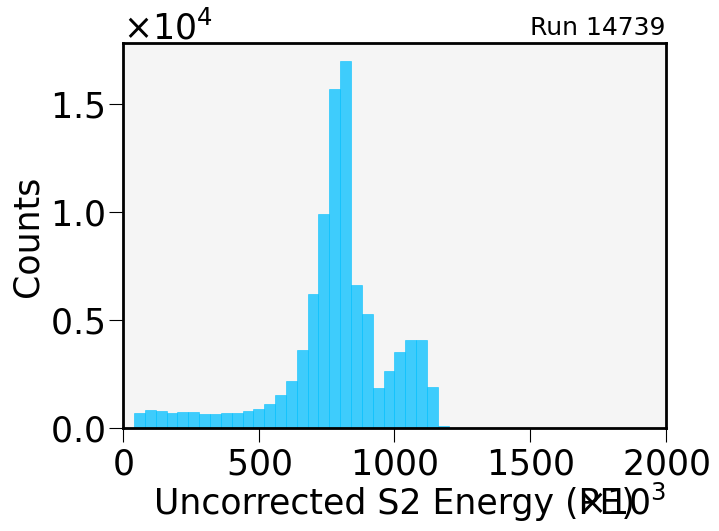

In [10]:
# Global
n_bins = 50
x_min, x_max = 0, 2000e3
x_edges = np.linspace(x_min, x_max, n_bins + 1)     # There are some events with greater energy

for i, entry in enumerate(RUNS_INFO):
    
    # Run info
    run_id   = entry["run_number"]
    run_long = entry["duration"]

    if run_id in SEL_RUNS:
        
        # Variables
        E2 = SEL_DATA[run_id]['S2e']
        print(f"Run {run_id} - S2 Energy range: [{E2.min():.2f}, {E2.max():.2f}] PE")
        
        # Histogram
        plt.figure(figsize=(7, 5))
        counts, bins, _ = plt.hist(E2, bins=x_edges, 
                                   color=crudo.pt.hist_colors[(i + 3) % len(crudo.pt.hist_colors)], alpha=0.75,
                                   ec=crudo.pt.hist_colors[(i + 3) % len(crudo.pt.hist_colors)], lw=0.5)
        
        # Plot
        plt.xlim(0, x_max)
        plt.xlabel('Uncorrected S2 Energy (PE)')
        plt.ylabel('Counts')
        # plt.yscale('log')
        plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
        plt.title(f'Run {run_id}', fontsize=18, loc='right')

        plt.gca().set_facecolor("whitesmoke")
        plt.show()

# Energy Behaviour

__Hypothesis 01:__ events with $S2w\geq50\,\mu\text{s}$ have a well-reconstructed energy.
<br>
__Hypothesis 02:__ events with $S2w\lt50\,\mu\text{s}$ are close to anode.

## Energy Correction

We first correct the $S1$ and $S2$ energies, to not consider any geometric effect.

In [94]:
# Main dataframe
TEST_DF = SEL_DATA[14739].copy()

# Variables
E1 = TEST_DF['S1e']
E2 = TEST_DF['S2e']
DT = TEST_DF['DT']
R  = TEST_DF['R']

# Dictionary to store fit parameters
FIT_PARAMETERS = {}

# Limits
S2W_CUT = 50        # μs
RAD_LIMIT = 400     # mm
DT_LIMIT  = 1320    # μs

# Masks
DT_mask = (DT < DT_LIMIT)
FV_mask = (R <= RAD_LIMIT) & (DT < DT_LIMIT)

In [95]:
FV_mask

11         True
16         True
18         True
19         True
22        False
          ...  
403572    False
403575    False
403576    False
403578    False
403580     True
Length: 96087, dtype: bool

In [96]:
DT_mask

11         True
16         True
18         True
19         True
22         True
          ...  
403572    False
403575     True
403576    False
403578    False
403580     True
Name: DT, Length: 96087, dtype: bool

Run 14739 Fit: m = (0.57 ± 0.00) PE/μs, b = (807.53 ± 0.96) PE
χ² / ndof = 5.48


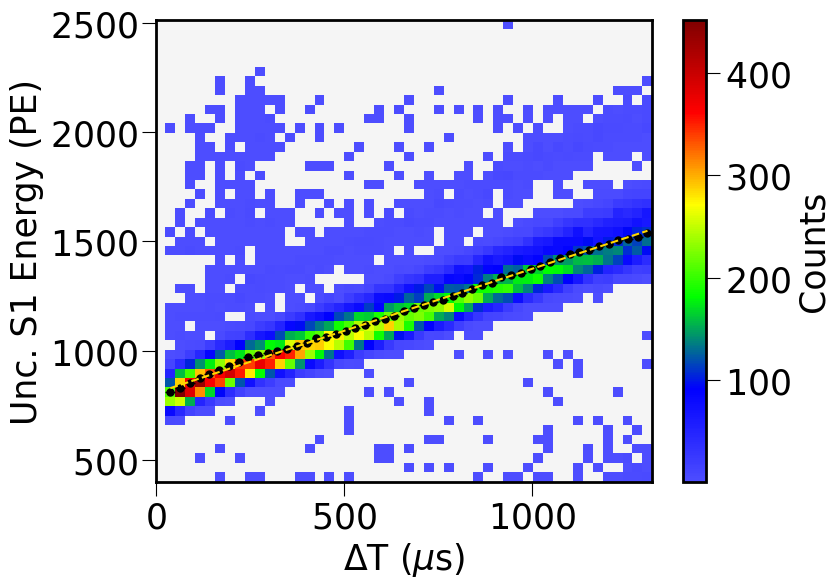

In [97]:
# Global
n_bins  = 50

# Masking 
E1_mask = E1[FV_mask]
DT_mask = DT[FV_mask]

# 2D histogram
S1e_DT_map, ex, ey = crudo.pt.hist_2D(DT_mask, E1_mask, x_bins=n_bins, y_bins=n_bins)                         
S1e_DT_map         = np.ma.masked_where(S1e_DT_map==0, S1e_DT_map)

# ----- Linear Fit ----- #
# Compute representative values for the fit
DT_centers, DT_errors, S1e_means, S1e_errors = crudo.ff.prefit_2D(DT_mask, E1_mask, bins=n_bins)
# Filter out points with zero error (bins with 1 event)
valid_points = S1e_errors > 0
DT_centers = DT_centers[valid_points];      DT_errors  = DT_errors[valid_points]
S1e_means  = S1e_means[valid_points];       S1e_errors = S1e_errors[valid_points]

# Definte the cost function + initial guess
least_squares = LeastSquares(DT_centers, S1e_means, S1e_errors, crudo.ff.linear_func)
init_guess = [10, S1e_means.min()]
# print(f'\nInitial guess: m = {init_guess[0]:.4f} PE/μs, b = {init_guess[1]:.4f} PE')

# Minimization process
m = Minuit(least_squares, *init_guess)
m.migrad()
m.hesse()

# Results
popt = m.values;  perr = m.errors
print(f'Run {run_id} Fit: m = ({popt[0]:.2f} ± {perr[0]:.2f}) PE/μs, b = ({popt[1]:.2f} ± {perr[1]:.2f}) PE')    
FIT_PARAMETERS["S1e"] = {"m_CV": popt[0], "m_err": perr[0], "b_CV": popt[1], "b_err": perr[1]}

# Reduced chi-square
chi2 = m.fval
ndof = len(DT_centers) - m.nfit
print(f"χ² / ndof = {chi2 / ndof:.2f}")

# ----- Plotting ----- #
plt.figure(figsize=(8, 6))

# Data
plt.pcolormesh(ex, ey, S1e_DT_map.T, cmap=crudo.pt.custom_hsv, shading='auto')    
cbar = plt.colorbar(label='Counts', shrink=1.0)

# Fit
fit_y = crudo.ff.linear_func(DT_centers, *popt)
plt.errorbar(DT_centers, S1e_means, xerr=DT_errors, yerr=S1e_errors, fmt='o', c='black', ecolor='black', lw=1.0, markersize=5)
plt.plot(DT_centers, fit_y, c='gold', ls='--', lw=1.5, zorder=3)

# ----- Styling ----- #
plt.xlabel('$\Delta$T ($\mu$s)')
plt.xlim(0, DT_mask.max())
plt.ylabel('Unc. S1 Energy (PE)')

plt.gca().set_facecolor("whitesmoke")
plt.show() 

Run 14739 fit: N0 = (821276.05 ± 687.36) PE, τ = (91.54 ± 8.81) ms
χ² / ndof = 4.6554


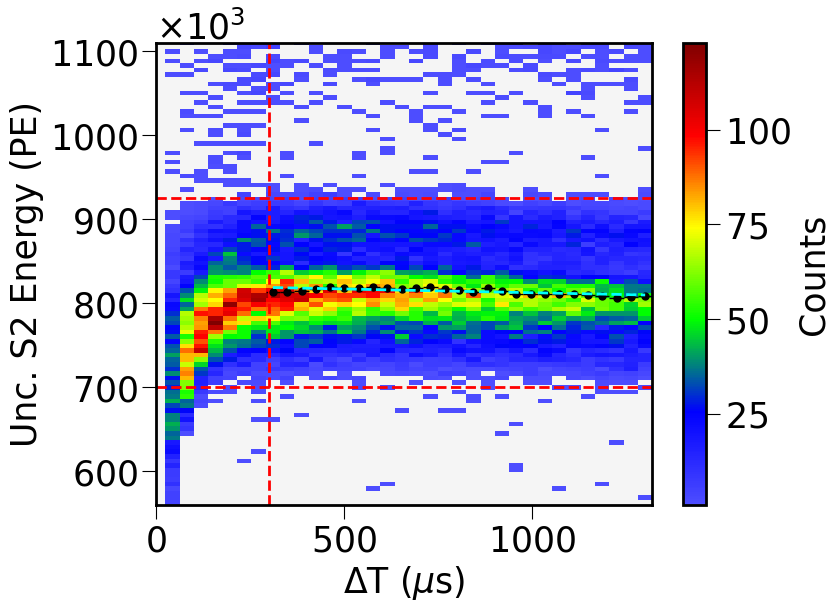

In [98]:
# Global
x_bins = 35
y_bins = 400

# Use exponential decay function with b = 0
def exp_bfixed(x, N0, tau):
    return crudo.ff.exponential_decay(x, N0, tau, 0)

# Masking
E2_mask  = E2[FV_mask]
DT_mask  = DT[FV_mask]

# 2D histogram
S2e_DT_map, ex, ey = crudo.pt.hist_2D(DT_mask, E2_mask, x_bins=x_bins, y_bins=y_bins)                         
S2e_DT_map         = np.ma.masked_where(S2e_DT_map==0, S2e_DT_map)

# ---- Exponential Fit ----- #
# Preliminary
DT_down = 300;    DT_up = DT_mask.max()
E2_down = 700e3;  E2_up = 925e3

# Filter the data for the fit
fit_region_mask = (DT_mask >= DT_down) & (DT_mask <= DT_up) & \
                  (E2_mask >= E2_down) & (E2_mask <= E2_up)
DT_fit = DT_mask[fit_region_mask]
E2_fit = E2_mask[fit_region_mask]

# Compute representative values for the fit
DT_centers, DT_errors, S2e_means, S2e_errors = crudo.ff.prefit_2D(DT_fit, E2_fit, bins=ex)
# Filter out points with zero error (bins with 1 event)
valid_points = S2e_errors > 0
DT_centers = DT_centers[valid_points];      DT_errors  = DT_errors[valid_points]
S2e_means  = S2e_means[valid_points];       S2e_errors = S2e_errors[valid_points]

# Definte the cost function + initial guess
least_squares = LeastSquares(DT_centers, S2e_means, S2e_errors, exp_bfixed)
init_guess = [S2e_means.max(), (DT_centers.max() - DT_centers.min()) / 2]
# print(f'\nInitial guess: N0 = {init_guess[0]:.4f} PE, tau = {init_guess[1]:.4f} μs')

# Minimization process
m = Minuit(least_squares, *init_guess)
m.migrad()
m.hesse()

# Results
popt = m.values;  perr = m.errors
print(f'Run {run_id} fit: N0 = ({popt[0]:.2f} ± {perr[0]:.2f}) PE, τ = ({popt[1] / 1e3:.2f} ± {perr[1] / 1e3:.2f}) ms')
FIT_PARAMETERS["S2e"] = {"N0_CV": popt[0], "N0_err": perr[0], "tau_CV": popt[1], "tau_err": perr[1]}

# Reduced chi-square
chi2 = m.fval
ndof = len(DT_centers) - m.nfit
print(f"χ² / ndof = {chi2 / ndof:.4f}")

# ----- Plotting ----- #
plt.figure(figsize=(8, 6))

# Data
plt.pcolormesh(ex, ey, S2e_DT_map.T, cmap=crudo.pt.custom_hsv, shading='auto')
cbar = plt.colorbar(label='Counts', shrink=1.0)

# Fit
fit_y = exp_bfixed(DT_centers, *popt)
plt.errorbar(DT_centers, S2e_means, xerr=DT_errors, yerr=S2e_errors, fmt='o', c='black', ecolor='black', lw=1.0, markersize=5)
plt.plot(DT_centers, fit_y, c='cyan', ls='--', lw=2.0, zorder=3)
plt.axvline(x=DT_down, c='red', ls='--')
plt.axhline(y=E2_down, c='red', ls='--')
plt.axhline(y=E2_up, c='red', ls='--')

# ----- Styling ----- #
plt.xlabel('$\Delta$T ($\mu$s)')
plt.xlim(0, DT_mask.max())
plt.ylabel('Unc. S2 Energy (PE)') 
plt.ylim(0.8*E2_down, 1.2*E2_up)
plt.ticklabel_format(axis='y', style='sci', scilimits=(3, 3))

plt.gca().set_facecolor("whitesmoke")
plt.show() 

In [ ]:
# Global
n_bins  = 50

# Fit parameters for energy corrections
CV_fit = [FIT_PARAMETERS['S1e']['m_CV'],  FIT_PARAMETERS['S1e']['b_CV']]
LT_fit = [FIT_PARAMETERS['S2e']['N0_CV'], FIT_PARAMETERS['S2e']['tau_CV']]

# Apply corrections
TEST_DF = crudo.ef.correct_S1e   (TEST_DF, CV_fit, DT_LIMIT, output_column='S1e_corr')          # S1 energy
TEST_DF = crudo.ef.correct_S2e_LT(TEST_DF, LT_fit, output_column='S2e_corr_LT')                 # S2 energy by lifetime
TEST_DF = crudo.ef.correct_S2e_map(TEST_DF, DT_LIMIT, xy_bins=n_bins, input_column='S2e_corr_LT')   # S2 energy by geometric map

Are the energies corrected?

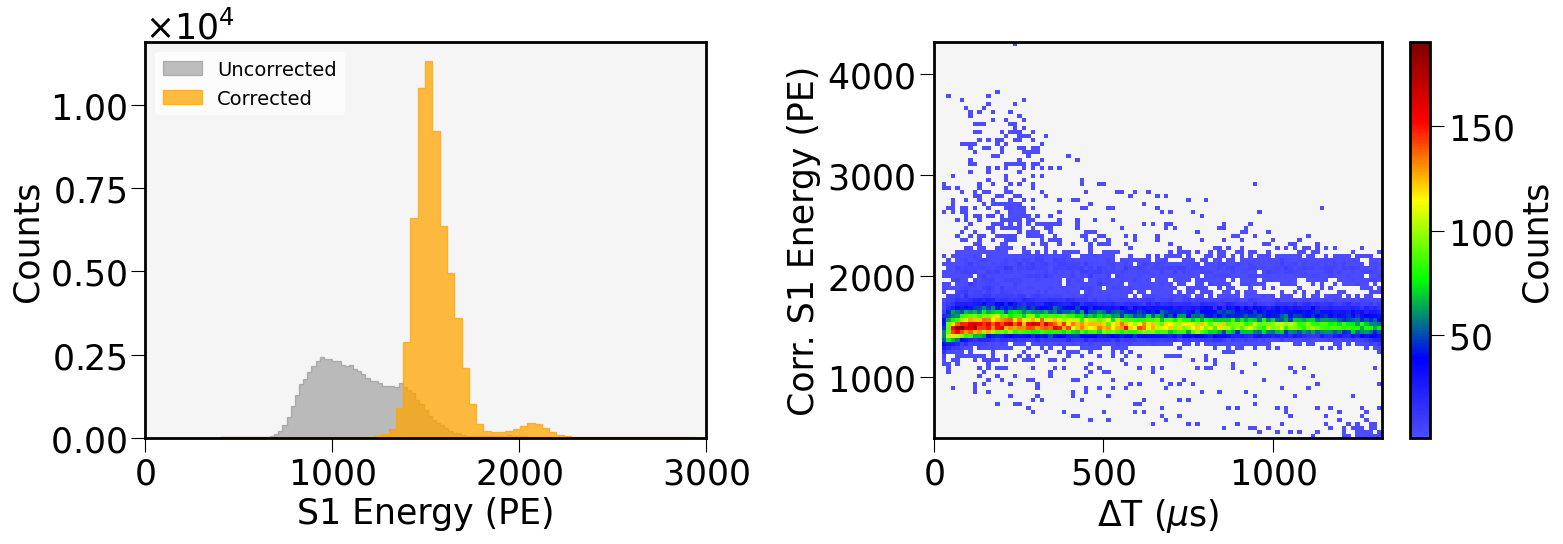

In [112]:
# Global
n_bins = 100
E1_min = 0; E1_max = 3e3

# Variables
E1      = TEST_DF['S1e']
E1_corr = TEST_DF['S1e_corr']
DT      = TEST_DF['DT']

# Masking
DT_mask  = (DT < DT_LIMIT)
E1_mask  = E1[DT_mask]
E1c_mask = E1_corr[DT_mask]
DT_mask  = DT[DT_mask]

# 2D histogram
S1e_DT_map, ex, ey = crudo.pt.hist_2D(DT_mask, E1c_mask, x_bins=n_bins, y_bins=n_bins)                     
S1e_DT_map         = np.ma.masked_where(S1e_DT_map == 0, S1e_DT_map)  # Zero values masked

# ----- Plotting ----- #
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left
axes[0].hist(E1_mask, bins=n_bins, histtype='stepfilled', lw=1.0, color='grey', alpha=0.50, ec='grey', label='Uncorrected')
axes[0].hist(E1c_mask, bins=n_bins, histtype='stepfilled', lw=1.0, color='orange', alpha=0.75, ec='orange', label='Corrected')
axes[0].set_xlabel('S1 Energy (PE)')
axes[0].set_xlim(E1_min, E1_max)
axes[0].set_ylabel('Counts')
axes[0].legend(loc='upper left', fontsize=14)
axes[0].set_facecolor('whitesmoke')

# Right
pcm = axes[1].pcolormesh(ex, ey, S1e_DT_map.T, cmap=crudo.pt.custom_hsv, shading='auto')
cbar = fig.colorbar(pcm, ax=axes[1], label='Counts')
axes[1].set_xlabel('$\Delta$T ($\mu$s)')
axes[1].set_xlim(0, DT_mask.max())
axes[1].set_ylabel('Corr. S1 Energy (PE)')
axes[1].set_facecolor('whitesmoke')

plt.tight_layout()
plt.show()

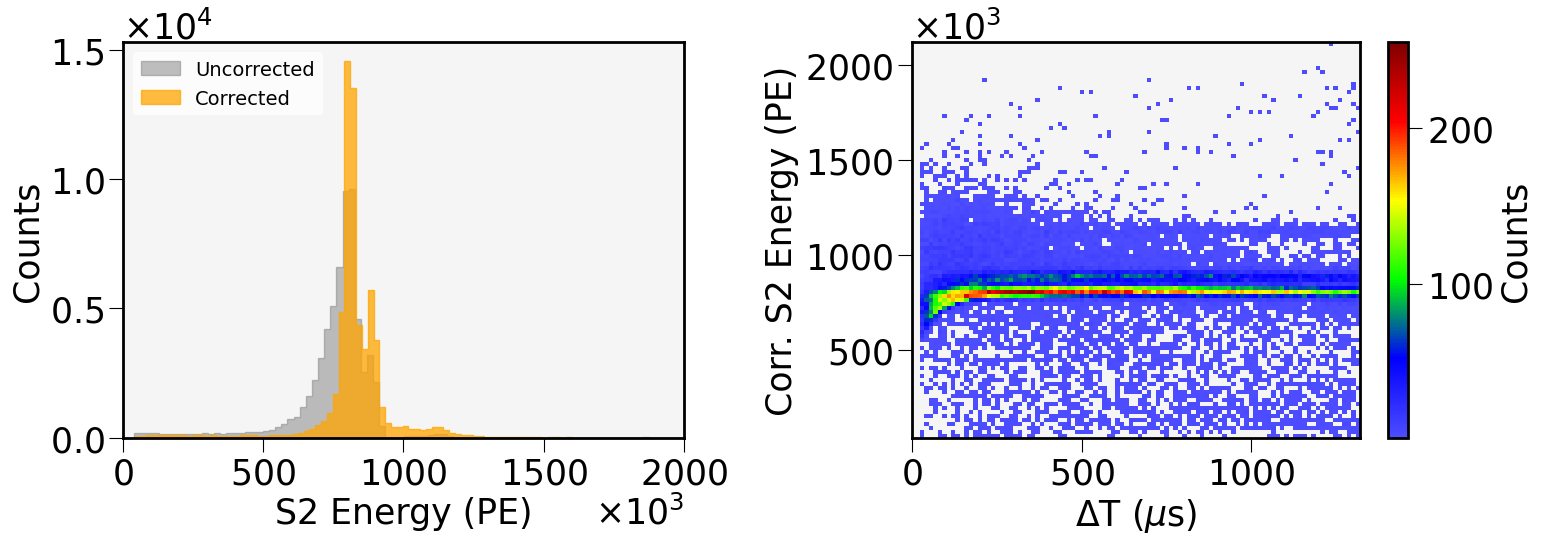

In [116]:
# Global
n_bins = 100
E2_min = 0;  E2_max = 2000e3

# Variables    
E2      = TEST_DF['S2e']
E2_corr = TEST_DF['S2e_corr']
DT      = TEST_DF['DT']

# Masking
DT_mask = (DT < DT_LIMIT)
E2_mask = E2[DT_mask]
E_mask  = E2_corr[DT_mask]
DT_mask = DT[DT_mask]

# 2D histogram
S2e_DT_map, ex, ey = crudo.pt.hist_2D(DT_mask, E_mask, x_bins=n_bins, y_bins=n_bins)                        
S2e_DT_map         = np.ma.masked_where(S2e_DT_map == 0, S2e_DT_map)

    # ----- Plotting ----- #
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left
axes[0].hist(E2_mask, bins=n_bins, histtype='stepfilled', lw=1.0, color='grey', alpha=0.50, ec='grey', label='Uncorrected')
axes[0].hist(E_mask, bins=n_bins, histtype='stepfilled', lw=1.0, color='orange', alpha=0.75, ec='orange', label='Corrected')
axes[0].set_xlabel('S2 Energy (PE)')
axes[0].set_xlim(E2_min, E2_max)
axes[0].set_ylabel('Counts')
axes[0].ticklabel_format(axis='x', style='sci', scilimits=(3,3))
axes[0].legend(loc='upper left', fontsize=14)
axes[0].set_facecolor('whitesmoke')

# Right
pcm = axes[1].pcolormesh(ex, ey, S2e_DT_map.T, cmap=crudo.pt.custom_hsv, shading='auto')
cbar = fig.colorbar(pcm, ax=axes[1], label='Counts')
axes[1].set_xlabel('$\Delta$T ($\mu$s)')
axes[1].set_xlim(0, DT_mask.max())
axes[1].set_ylabel('Corr. S2 Energy (PE)')
axes[1].ticklabel_format(axis='y', style='sci', scilimits=(3,3))
axes[1].set_facecolor('whitesmoke')

plt.tight_layout()
plt.show()

## $S2$ Width Comparison

In [117]:
# Dataframes to be compared
s2_more_50_df = TEST_DF[TEST_DF['S2w'] >= S2W_CUT]
s2_less_50_df = TEST_DF[TEST_DF['S2w'] < S2W_CUT]

# Extras
list_of_dfs  = [s2_more_50_df, s2_less_50_df]
descriptions = [f'S2 Width >= {S2W_CUT} μs', f'S2 Width <  {S2W_CUT} μs']

print(f"Events ({descriptions[0]}): {s2_more_50_df['event'].nunique()}")
print(f"Events ({descriptions[1]}): {s2_less_50_df['event'].nunique()}")

Events (S2 Width >= 50 μs): 73001
Events (S2 Width <  50 μs): 23086


Let's find the ubication of these populations!

### Radial

R² (S2 Width >= 50 μs): [1.60, 233644.54] mm²
R² (S2 Width <  50 μs): [3.35, 237345.68] mm²


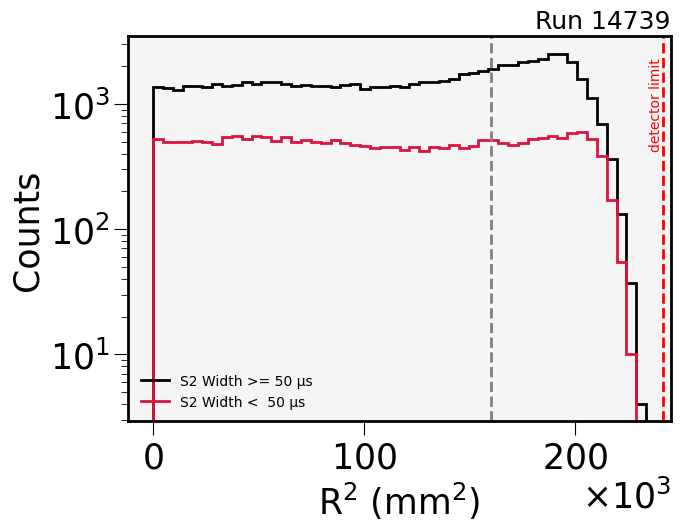

In [118]:
# Global
n_bins = 50
plt.figure(figsize=(7, 5))

# ----- Define the Binning ----- #
R2_base = s2_more_50_df['X']**2 + s2_more_50_df['Y']**2
_, plot_edges = np.histogram(R2_base, bins=n_bins)

for i, dataframe in enumerate(list_of_dfs):

    # Variables
    R2 = dataframe['X']**2 + dataframe['Y']**2
    print(f"R² ({descriptions[i]}): [{R2.min():.2f}, {R2.max():.2f}] mm²")

    # # Masking
    # DT = dataframe['DT']
    # time_mask = (DT < DT_LIMIT)
    # R2 = R2[time_mask]
    
    # Histogram
    counts, bin_edges = np.histogram(R2, bins=plot_edges)

    # --- Plotting --- #
    plt.stairs(counts, bin_edges, label=f'{descriptions[i]}', 
               fill=False, lw=2.0, ec=crudo.pt.hist_colors[i % len(crudo.pt.hist_colors)])
    
# --- Styling --- #
plt.xlabel('R$^{2}$ (mm$^{2}$)')
plt.ylabel('Counts')
plt.yscale('log')
plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
plt.legend(loc='lower left', fontsize=10, facecolor='None')
plt.title(f'Run 14739', fontsize=18, loc='right')

# Radial limit
plt.axvline(x=crudo.pt.N100_rad**2, c='red', ls='--')
plt.text(crudo.pt.N100_rad**2, 1e3, 'detector limit', c='red', va='center',  ha='right',  rotation=90, fontsize=10)
plt.axvline(x=RAD_LIMIT**2, c='gray', ls='--')

plt.gca().set_facecolor("whitesmoke")
plt.show()

### DT

ΔT (S2 Width >= 50 μs): [27.53, 1467.34] mm²
ΔT (S2 Width <  50 μs): [24.13, 1446.41] mm²


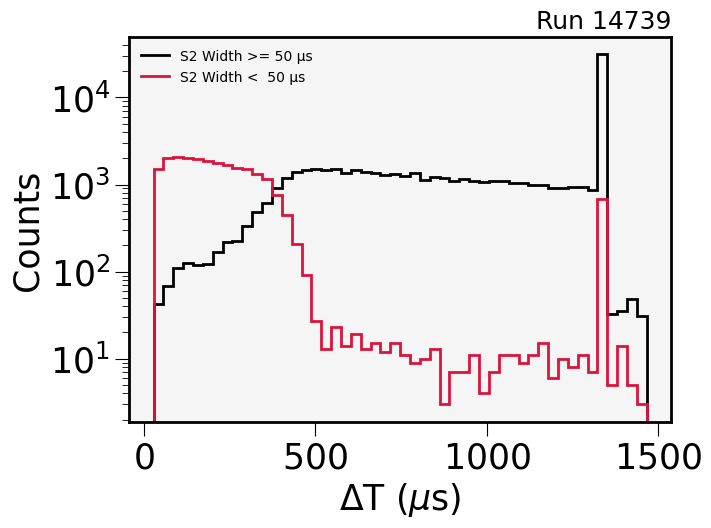

In [119]:
# Global
n_bins = 50
plt.figure(figsize=(7, 5))

# ----- Define the Binning ----- #
DT_base = s2_more_50_df['DT']
_, plot_edges = np.histogram(DT_base, bins=n_bins)

for i, dataframe in enumerate(list_of_dfs):

    # Variables
    DT = dataframe['DT']
    print(f"ΔT ({descriptions[i]}): [{DT.min():.2f}, {DT.max():.2f}] mm²")

    # # Masking
    # R  = np.sqrt(dataframe['X']**2 + dataframe['Y']**2)
    # rad_mask = (R <= RAD_LIMIT)
    # DT = DT[rad_mask]
    
    # Histogram
    counts, bin_edges = np.histogram(DT, bins=plot_edges)

    # --- Plotting --- #
    plt.stairs(counts, bin_edges, label=f'{descriptions[i]}', 
               fill=False, lw=2.0, ec=crudo.pt.hist_colors[i % len(crudo.pt.hist_colors)])
    
# --- Styling --- #
plt.xlabel('$\Delta$T ($\mu$s)')
# plt.xticks(plot_edges, rotation=90, fontsize=8)
plt.ylabel('Counts')
plt.yscale('log')
plt.legend(loc='upper left', fontsize=10, facecolor='None')
plt.title(f'Run 14739', fontsize=18, loc='right')

# plt.axvline(x=DT_LIMIT, c='gray', ls='--')

plt.gca().set_facecolor("whitesmoke")
plt.show()

#### How is the behavior of red population before and after $500\,\mu\text{s}$?

In [148]:
dt_more_500_df = s2_less_50_df[s2_less_50_df['DT'] >= 500]
dt_less_500_df = s2_less_50_df[s2_less_50_df['DT'] < 500]

In [149]:
dt_more_500_df

,event,time,s1_peak,s2_peak,nS1,nS2,S1w,S1h,S1e,S1t,...,R,Phi,Xrms,Yrms,S1e_corr,S2e_corr_LT,x_bin,y_bin,S2e_norm_factor,S2e_corr
237,10957,1.737644e+09,0,0,1,1,600.0,364.865906,1962.085449,269625.0,...,226.574255,-0.837005,25.221391,25.273319,1944.131143,3.352721e+05,30,17,1.015264,3.302315e+05
753,34498,1.737645e+09,0,0,1,1,700.0,294.665161,1632.955444,261900.0,...,384.103578,0.116682,18.539069,19.515747,1616.999296,5.727860e+04,40,26,0.915967,6.253347e+04
1078,49674,1.737645e+09,0,0,1,1,875.0,342.219971,2004.330811,263400.0,...,394.430251,1.017266,20.667194,20.984189,1985.111920,9.853994e+04,32,38,0.949155,1.038186e+05
1177,53867,1.737646e+09,0,0,1,1,775.0,371.632477,2132.740967,264650.0,...,173.396991,-2.152929,22.340489,20.166014,2114.001725,9.250163e+04,20,18,1.015418,9.109707e+04
1342,61791,1.737646e+09,0,0,1,1,1050.0,345.861359,2013.348022,261050.0,...,250.472656,-2.190435,17.684022,18.368837,1995.220375,5.616848e+04,18,16,1.023800,5.486277e+04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
402186,2515043,1.737729e+09,0,0,1,1,775.0,305.109650,1733.420044,215900.0,...,280.814149,-2.693243,28.134301,28.042171,1690.862729,8.194556e+05,14,19,0.992256,8.258508e+05
402467,2528819,1.737729e+09,0,0,1,1,550.0,277.122040,1570.458252,263800.0,...,390.072023,2.156589,18.790565,18.130960,1557.297595,5.317026e+04,15,37,0.956035,5.561538e+04
402479,2529344,1.737729e+09,0,0,1,1,775.0,305.095795,1762.496704,720025.0,...,134.004873,-0.110708,317.255106,234.498037,2084.498870,1.639861e+06,29,23,1.015002,1.615624e+06
402569,2532739,1.737729e+09,0,0,1,1,625.0,327.160217,1824.491211,211775.0,...,244.209160,1.734125,13.365682,12.867217,1776.478308,4.477199e+04,22,34,1.012840,4.420441e+04


In [150]:
dt_less_500_df

,event,time,s1_peak,s2_peak,nS1,nS2,S1w,S1h,S1e,S1t,...,R,Phi,Xrms,Yrms,S1e_corr,S2e_corr_LT,x_bin,y_bin,S2e_norm_factor,S2e_corr
49,2606,1.737644e+09,0,0,1,1,575.0,165.029572,920.618591,1474350.0,...,140.621472,2.045405,29.011612,29.124162,1622.386943,829660.296447,21,29,1.021933,811853.567753
58,2907,1.737644e+09,0,0,1,1,600.0,176.720078,975.779175,1314075.0,...,307.823002,-2.227551,27.248458,27.113351,1556.419151,865936.502946,16,14,0.975337,887833.449252
86,3859,1.737644e+09,0,0,1,1,650.0,157.713715,924.275146,1480775.0,...,420.391261,2.452073,31.876736,31.729760,1634.541522,772212.842701,11,35,0.913365,845459.002881
106,4811,1.737644e+09,0,0,1,1,900.0,141.613007,850.708557,1511675.0,...,194.201983,-1.540196,25.929544,26.370605,1536.979016,753650.107172,24,16,1.008883,747014.209569
144,6022,1.737644e+09,0,0,1,1,675.0,207.807800,1185.021240,1247475.0,...,386.607602,-1.059890,32.948410,31.902674,1819.764391,847375.198089,32,10,0.951772,890312.928437
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403517,2573822,1.737731e+09,0,0,1,1,550.0,175.813217,969.482422,1354575.0,...,148.486579,-1.225079,25.016797,25.938554,1585.529521,813015.861972,26,18,1.033249,786853.698784
403520,2573976,1.737731e+09,0,0,1,1,675.0,148.778259,910.730103,1377550.0,...,371.528967,-1.241443,29.217847,29.136289,1510.122946,775252.933718,29,10,0.941736,823216.559882
403531,2574795,1.737731e+09,0,0,1,1,600.0,157.539871,919.805420,1381325.0,...,387.531515,-0.960163,32.403172,31.633233,1527.752789,774091.665930,33,11,0.970194,797873.089922
403543,2575152,1.737731e+09,0,0,1,1,825.0,146.828751,872.844604,1465075.0,...,228.168303,-1.632676,25.888245,25.511142,1530.032534,765573.289840,23,15,0.993533,770556.814436


### $S1$/$S2$ Energies

In [124]:
s2_more_50_df

,event,time,s1_peak,s2_peak,nS1,nS2,S1w,S1h,S1e,S1t,...,R,Phi,Xrms,Yrms,S1e_corr,S2e_corr_LT,x_bin,y_bin,S2e_norm_factor,S2e_corr
11,331,1.737644e+09,0,0,1,1,600.0,262.389038,1538.280273,357050.0,...,380.468038,-2.129957,38.065646,30.299818,1572.698677,735843.741702,16,11,0.912345,8.065413e+05
16,716,1.737644e+09,0,0,1,1,925.0,195.171722,1217.824463,880350.0,...,318.345852,1.879273,26.538464,27.759102,1548.628742,803335.705399,20,36,0.990450,8.110818e+05
18,842,1.737644e+09,0,0,1,1,625.0,211.819778,1256.688110,914375.0,...,144.772910,0.166921,26.632095,27.044348,1624.402378,880588.536181,30,25,0.990378,8.891440e+05
19,849,1.737644e+09,0,0,1,1,625.0,206.751801,1214.081055,763975.0,...,76.670220,-0.959927,26.917435,26.519437,1465.529471,852394.636922,26,21,1.006008,8.473042e+05
22,1038,1.737644e+09,0,0,1,1,825.0,216.178925,1266.604736,709225.0,...,452.135893,-2.735193,17.207454,19.072820,1494.277645,116344.818856,7,17,0.588538,1.976844e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403572,2576349,1.737731e+09,0,0,1,1,600.0,269.677124,1566.921387,276450.0,...,296.925891,2.072156,28.449638,29.316708,1554.726464,821827.182945,18,35,0.998081,8.234077e+05
403575,2576384,1.737731e+09,0,0,1,1,700.0,206.194489,1233.543701,768825.0,...,417.525392,1.013437,29.897791,27.951866,1491.558919,708392.730157,33,38,0.935131,7.575334e+05
403576,2576405,1.737731e+09,0,0,1,1,725.0,258.907990,1458.127563,270925.0,...,355.614497,0.637850,29.564018,29.075978,1444.939944,685662.930070,36,33,0.941780,7.280500e+05
403578,2576426,1.737731e+09,0,0,1,1,725.0,362.998657,2002.539429,276850.0,...,410.921965,1.376452,34.064693,29.632113,1987.950826,989597.669605,27,40,0.916298,1.079996e+06


S1 Energy (S2 Width >= 50 μs): [384.96, 4310.89] mm²
S1 Energy (S2 Width <  50 μs): [390.88, 3646.72] mm²


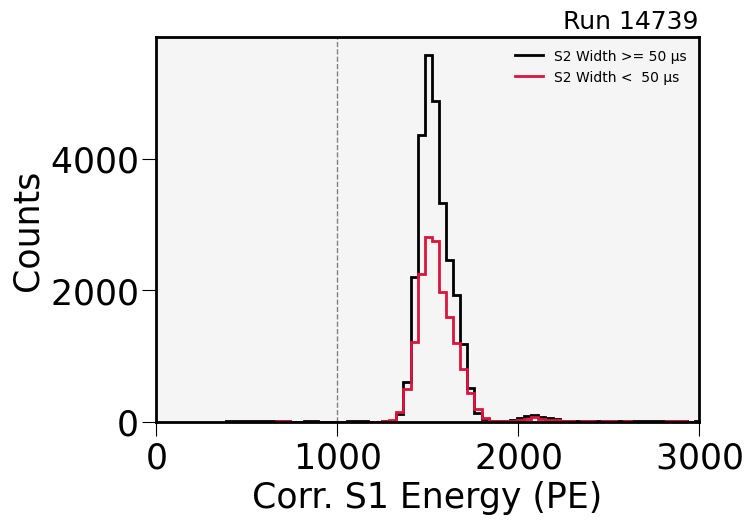

In [132]:
# Global
n_bins = 100
E1_min = 0; E1_max = 3e3
plt.figure(figsize=(7, 5))

# ----- Define the Binning ----- #
S1e_base = s2_more_50_df['S1e_corr']
_, plot_edges = np.histogram(S1e_base, bins=n_bins)

for i, dataframe in enumerate(list_of_dfs):

    # Variables
    S1e = dataframe['S1e_corr']
    print(f"S1 Energy ({descriptions[i]}): [{S1e.min():.2f}, {S1e.max():.2f}] mm²")

    # Masking
    DT = dataframe['DT']
    R  = np.sqrt(dataframe['X']**2 + dataframe['Y']**2)
    FV_mask = (R <= RAD_LIMIT) & (DT < DT_LIMIT)
    S1e = S1e[FV_mask]
    
    # Histogram
    counts, bin_edges = np.histogram(S1e, bins=plot_edges)

    # --- Plotting --- #
    plt.stairs(counts, bin_edges, label=f'{descriptions[i]}', 
               fill=False, lw=2.0, ec=crudo.pt.hist_colors[i % len(crudo.pt.hist_colors)])
    
# --- Styling --- #
plt.xlabel('Corr. S1 Energy (PE)')
plt.xlim(E1_min, E1_max)
plt.ylabel('Counts')
# plt.yscale('log')
plt.legend(loc='upper right', fontsize=10, facecolor='None')
plt.title(f'Run 14739', fontsize=18, loc='right')

plt.axvline(x=1000, c='gray', ls='--', lw=1.0)

plt.gca().set_facecolor("whitesmoke")
plt.show()

S2 Energy (S2 Width >= 50 μs): [41574.64, 2242661.82] mm²
S2 Energy (S2 Width <  50 μs): [40169.51, 1958936.17] mm²


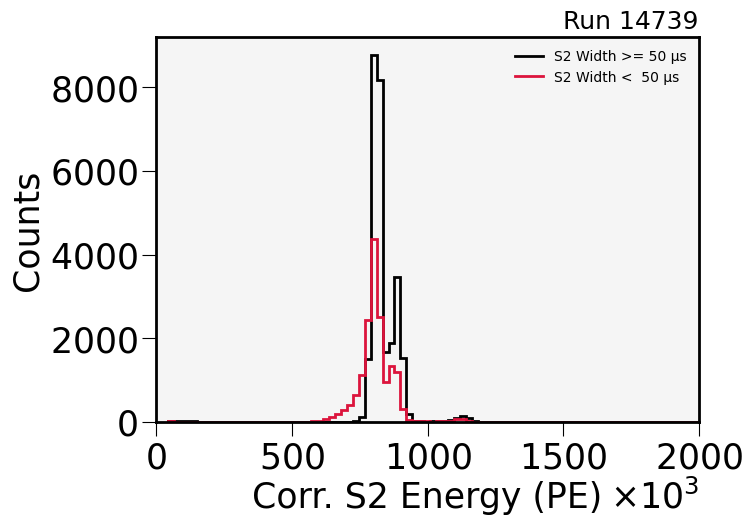

In [147]:
# Global
n_bins = 100
E2_min = 0;  E2_max = 2000e3
plt.figure(figsize=(7, 5))

# ----- Define the Binning ----- #
S2e_base = s2_more_50_df['S2e_corr']
_, plot_edges = np.histogram(S2e_base, bins=n_bins)

for i, dataframe in enumerate(list_of_dfs):

    # Variables
    S2e = dataframe['S2e_corr']
    print(f"S2 Energy ({descriptions[i]}): [{S2e.min():.2f}, {S2e.max():.2f}] mm²")

    # Masking
    DT = dataframe['DT']
    R  = np.sqrt(dataframe['X']**2 + dataframe['Y']**2)
    FV_mask = (R <= RAD_LIMIT) & (DT < DT_LIMIT)
    S2e = S2e[FV_mask]
    
    # Histogram
    counts, bin_edges = np.histogram(S2e, bins=plot_edges)

    # --- Plotting --- #
    plt.stairs(counts, bin_edges, label=f'{descriptions[i]}', 
               fill=False, lw=2.0, ec=crudo.pt.hist_colors[i % len(crudo.pt.hist_colors)])
    
# --- Styling --- #
plt.xlabel('Corr. S2 Energy (PE)')
plt.xlim(E2_min, E2_max)
plt.ylabel('Counts')
# plt.yscale('log')
plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
plt.legend(loc='upper right', fontsize=10, facecolor='None')
plt.title(f'Run 14739', fontsize=18, loc='right')

plt.gca().set_facecolor("whitesmoke")
plt.show()

In [140]:
# # Global
# n_bins = 50
# plt.figure(figsize=(7, 5))

# # ----- Define the Binning ----- #
# E_ratio_base = S1e_base / S2e_base
# _, plot_edges = np.histogram(E_ratio_base, bins=n_bins, range=(0, 0.005))

# for i, dataframe in enumerate(list_of_dfs):

#     # Variables
#     S1e = dataframe['S1e_corr']
#     S2e = dataframe['S2e_corr']
#     E_ratio = S1e / S2e
#     print(f"S1e / S2e ({descriptions[i]}): [{E_ratio.min():.2f}, {E_ratio.max():.2f}] mm²")

#     # # Masking
#     # DT = dataframe['DT']
#     # R  = np.sqrt(dataframe['X']**2 + dataframe['Y']**2)
#     # FV_mask = (R <= RAD_LIMIT) & (DT < DT_LIMIT)
#     # E_ratio = E_ratio[FV_mask]
    
#     # Histogram
#     counts, bin_edges = np.histogram(E_ratio, bins=plot_edges)

#     # --- Plotting --- #
#     plt.stairs(counts, bin_edges, label=f'{descriptions[i]}', 
#                fill=False, lw=2.0, ec=crudo.pt.hist_colors[i % len(crudo.pt.hist_colors)])
    
# # --- Styling --- #
# plt.xlim(0, 0.005)
# plt.xlabel('S1e / S2e')
# plt.ylabel('Counts')
# # plt.yscale('log')
# plt.legend(loc='upper right', fontsize=10, facecolor='None')
# plt.title(f'Run 14739', fontsize=18, loc='right')

# plt.gca().set_facecolor("whitesmoke")
# plt.show()

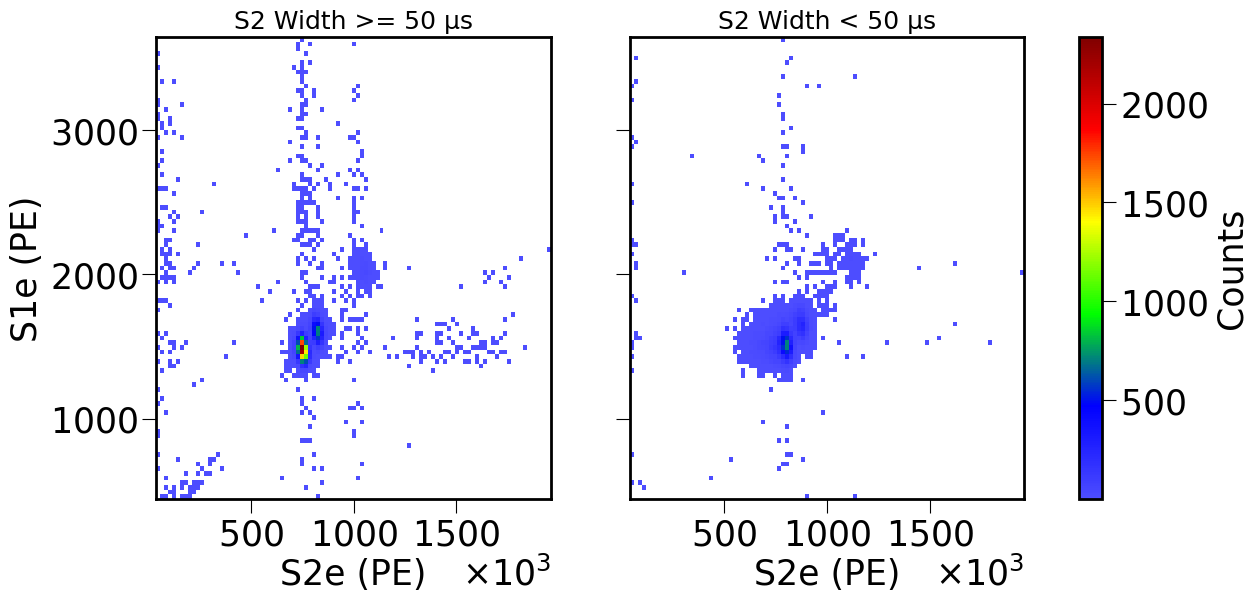

In [146]:
n_bins = 100
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for i, dataframe in enumerate(list_of_dfs):

    # Variables
    S1e = dataframe['S1e_corr']
    S2e = dataframe['S2e_corr']
    
    # Masking
    DT = dataframe['DT']
    R  = np.sqrt(dataframe['X']**2 + dataframe['Y']**2)
    FV_mask = (R <= RAD_LIMIT) & (DT < DT_LIMIT)
    S1e = S1e[FV_mask];  S2e = S2e[FV_mask]

    # 2D histogram
    S2e_S1e_map, ex, ey = crudo.pt.hist_2D(S2e, S1e, x_bins=n_bins, y_bins=n_bins)
    S2e_S1e_map         = np.ma.masked_where(S2e_S1e_map==0, S2e_S1e_map)

    # Store the 2D histogram for each dataframe
    if i == 0:
        S2e_S1e_map_more = S2e_S1e_map
    else:
        S2e_S1e_map_less = S2e_S1e_map

# Determine the common color scale limits
vmin = min(S2e_S1e_map_more.min(), S2e_S1e_map_less.min())
vmax = max(S2e_S1e_map_more.max(), S2e_S1e_map_less.max())

# --- Plotting --- #
# Iterate again to plot each 2D histogram
for i, (dataframe, title) in enumerate(zip([S2e_S1e_map_more, S2e_S1e_map_less], ['S2 Width >= 50 μs', 'S2 Width < 50 μs'])):
    im = axes[i].pcolormesh(ex, ey, dataframe.T, cmap=crudo.pt.custom_hsv, shading='auto', vmin=vmin, vmax=vmax)
    axes[i].set_title(title, fontsize=18)
    axes[i].set_xlabel('S2e (PE)')
    axes[i].ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
    # axes[i].axhline(y=1500, color='red', linestyle='--', linewidth=1.5)
    if i == 0:
        axes[i].set_ylabel('S1e (PE)')

# Add a common colorbar
cbar = fig.colorbar(im, ax=axes, location='right', shrink=1.0, label='Counts')

# plt.tight_layout()
plt.show()
